In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

In [3]:
virulence_matches = pd.read_csv("../data/ecoli/summary_virulence.txt", sep="\t")
db = pd.read_csv("../refgenes_latest.csv")
vir_categ = pd.read_csv("../vf_list.txt", sep="\t")

In [4]:
def transform_df(df):
    """
    Transforms an AMR category DataFrame into a binary matrix (0/1) indicating the presence of resistance genes.
    Adds an "MDR" column with 1 if three or more antibiotic classes (excluding "Efflux" and "ESBL (AmpC type)") have resistance.
    
    Parameters:
    df (pd.DataFrame): DataFrame with AMR categories as columns and resistance genes as values.
    
    Returns:
    pd.DataFrame: Transformed DataFrame with 0s and 1s, including an "MDR" column.
    """
    # Convert all values to string to handle NaN values correctly
    df_binary = df.iloc[:, 1:].notna().astype(int)
    
    # Add back the first two columns (sample identifiers)
    df_binary.insert(0, df.columns[0], df.iloc[:, 0])

    return df_binary

In [5]:
vir = transform_df(virulence_matches)

In [6]:
def plot_amr_category_frequency(df_binary):
    """
    Plots the frequency of resistance presence by AMR category as a bar plot with a secondary axis.
    The "MDR" bar is highlighted with alpha = 0.5.
    
    Parameters:
    df_binary (pd.DataFrame): Binary AMR DataFrame with 0s and 1s.
    """
    # Summing across rows to get frequency per category
    amr_frequencies = df_binary.iloc[:, 1:].sum().sort_values(ascending=False)

    # Plot setup
    fig, ax1 = plt.subplots(figsize=(12, 9))
    
    # Primary axis - Frequency
    bars = ax1.bar(amr_frequencies.index, amr_frequencies.values, color='xkcd:salmon', label='Frequency', alpha=0.6)
    ax1.set_xlabel("VF Category")
    ax1.set_ylabel("Frequency")
    ax1.set_xticklabels(amr_frequencies.index, rotation=45, ha="right")
    
    plt.title("E. coli")
    plt.tight_layout()
    plt.savefig("../out/vir_ecoli.svg", format="svg", dpi=150)
    plt.savefig("../out/vir_ecoli.png", format="png", dpi=150)

    plt.show();

/tmp/ipykernel_6118/812283800.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(amr_frequencies.index, rotation=45, ha="right")


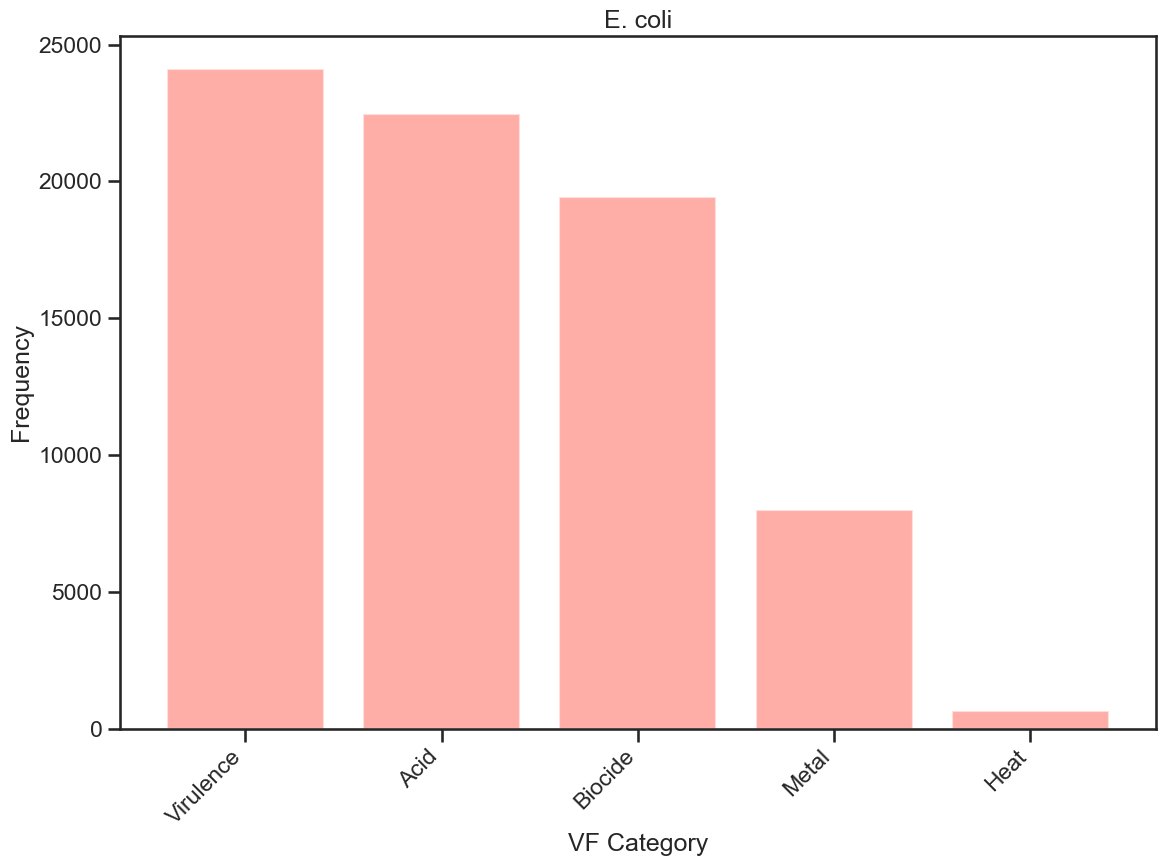

In [7]:
plot_amr_category_frequency(vir)

In [8]:
dic_unmatched = {
    'aaiC': 'toxin',
    'aap': 'adhesin',
    'aar': 'miscellanous',
    'aatA': 'adhesin',
    'afaC': 'adhesin',
    'agg4A': 'adhesin',
    'agg4D': 'adhesin',
    'agg5A': 'adhesin',
    'aggR': 'adhesin',
    'air': 'adhesin',
    'bmaE': 'adhesin',
    'capU': 'miscellanous',
    'cnf2': 'toxin',
    'cnf3': 'toxin',
    'eatA': 'toxin',
    'ehxA': 'toxin',
    'eilA': 'miscellanous',
    'epeA': 'toxin',
    'espB': 'toxin',
    'espF': 'toxin',
    'espI': 'toxin',
    'etpD': 'toxin',
    'f17a': 'adhesin',
    'f17g': 'adhesin',
    'fedA': 'adhesin',
    'fedF': 'adhesin',
    'fim41a': 'adhesin',
    'hlyA-alpha': 'toxin',
    'hlyE': 'toxin',
    'iha': 'adhesin',
    'ipaD': 'toxin',
    'ipaH1': 'toxin',
    'ipaH2': 'toxin',
    'ipaH4': 'toxin',
    'ireA': 'iron acquisition',
    'iss': 'iron acquisition',
    'katP': 'toxin',
    'lngA': 'adhesin',
    'lpfA': 'adhesin',
    'lpfA1': 'adhesin',
    'lpfA2': 'adhesin',
    'ltcA': 'toxin',
    'mchB': 'toxin',
    'mchF': 'toxin',
    'nfaE': 'adhesin',
    'nleB': 'toxin',
    'papG-I': 'adhesin',
    'papG-II': 'adhesin',
    'papG-III': 'adhesin',
    'perA': 'adhesin',
    'pic': 'toxin',
    'rmpA': 'to define',
    'rmpC': 'to define',
    'rmpD': 'to define',
    'saa': 'adhesin',
    'sab': 'to define',
    'senB': 'toxin',
    'sepA': 'toxin',
    'sigA': 'toxin',
    'sslE': 'to define',
    'sta1': 'toxin',
    'stb': 'toxin',
    'stxA1a': 'toxin',
    'stxA1c': 'toxin',
    'stxA1d': 'toxin',
    'stxA2a': 'toxin',
    'stxA2b': 'toxin',
    'stxA2c': 'toxin',
    'stxA2d': 'toxin',
    'stxA2e': 'toxin',
    'stxA2f': 'toxin',
    'stxA2g': 'toxin',
    'stxB1a': 'toxin',
    'stxB1c': 'toxin',
    'stxB1d': 'toxin',
    'stxB2a': 'toxin',
    'stxB2b': 'toxin',
    'stxB2c': 'toxin',
    'stxB2d': 'toxin',
    'stxB2e': 'toxin',
    'stxB2f': 'toxin',
    'stxB2g': 'toxin',
    'subA': 'toxin',
    'subB': 'toxin',
    'tccP': 'adhesin',
    'tsh': 'toxin',
    'vactox': 'toxin',
    'virF': 'toxin'
}

In [9]:
def extract_virulence_categories(df, gene_category_df, dic_unmatched):
    # Split and expand Virulence column
    vir_split = df['Virulence'].fillna('').str.split(',')
    all_virulence_factors = sorted(set(factor for sublist in vir_split for factor in sublist if factor))
    
    # Binary matrix
    virulence_matrix = pd.DataFrame(
        [[int(factor in row) for factor in all_virulence_factors] for row in vir_split],
        columns=all_virulence_factors,
        index=df['Isolate']
    )
    
    # Primary mapping
    gene_to_category = gene_category_df.set_index('gene')['category'].to_dict()
    
    # Final mapping with fallback to dic_unmatched
    final_category_map = {}
    undefined_genes = []

    for gene in virulence_matrix.columns:
        if gene in gene_to_category:
            final_category_map[gene] = gene_to_category[gene]
        elif gene in dic_unmatched:
            final_category_map[gene] = dic_unmatched[gene]
        else:
            final_category_map[gene] = 'not defined'
            undefined_genes.append(gene)
    
    # Rename columns to category names
    categorized_matrix = virulence_matrix.rename(columns=final_category_map)
    
    # Aggregate by category
    category_matrix = categorized_matrix.groupby(axis=1, level=0).sum()

    return category_matrix, undefined_genes


In [10]:
vcateg, undefined_genes = extract_virulence_categories(virulence_matches, vir_categ, dic_unmatched)

/tmp/ipykernel_6118/3247471084.py:33: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  category_matrix = categorized_matrix.groupby(axis=1, level=0).sum()


In [11]:
vcateg

,adhesin,invasin,iron acquisition,miscellanous,to define,toxin
Isolate,,,,,,
1085_F1S1R3D1B1P5A03,2,0,11,0,0,4
1085_F1S1R3D1B1P5A05,2,0,12,0,2,4
1085_F1S1R3D1B1P5A06,5,0,5,0,2,3
1085_F1S1R3D1B1P5A09,1,0,1,1,0,0
1085_F1S1R3D1B1P5A10,9,0,7,0,3,3
...,...,...,...,...,...,...
SRR9997955,3,1,1,0,2,3
SRR9998284,10,1,5,0,2,5
SRR9998287,2,0,11,0,2,3


In [12]:
def plot_virulence_category_frequency(df_binary):
    """
    Plots the frequency of virulence factor presence by category as a bar plot.

    Parameters:
    df_binary (pd.DataFrame): Binary VF DataFrame with 0s and 1s (Isolates x Categories).
    """
    # Sum per category
    vir_frequencies = df_binary.sum().sort_values(ascending=False)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 9))
    bars = ax.bar(
        vir_frequencies.index,
        vir_frequencies.values,
        color='xkcd:salmon',
        alpha=0.6
    )

    ax.set_xlabel("Virulence Category")
    ax.set_ylabel("Frequency")
    ax.set_title("E. coli")
    ax.set_facecolor("white")
    ax.tick_params(axis='x', rotation=45)

    sns.despine()
    plt.tight_layout()
    plt.savefig("../out/vir_categ_ecoli.svg", format="svg", dpi=150)
    plt.savefig("../out/vir_categ_ecoli.png", format="png", dpi=150)
    plt.show()

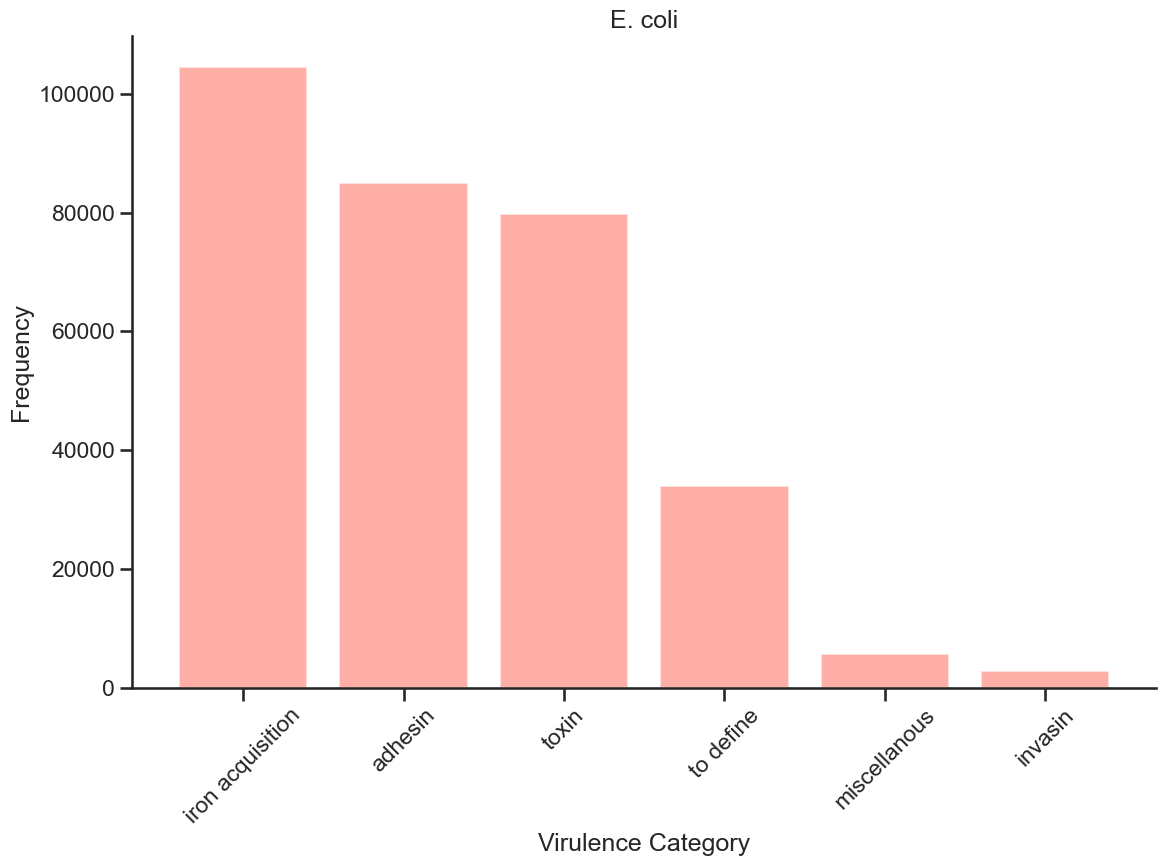

In [13]:
plot_virulence_category_frequency(vcateg)

In [14]:
def extract_virulence_features(df):
    vir_split = df['Virulence'].fillna('').str.split(',')
    all_virulence_factors = sorted(set(factor for sublist in vir_split for factor in sublist if factor))

    virulence_matrix = pd.DataFrame(
        [[int(factor in row) for factor in all_virulence_factors] for row in vir_split],
        columns=all_virulence_factors,
        index=df['Isolate']
    )

    return virulence_matrix

In [15]:
vscore = extract_virulence_features(virulence_matches)

In [16]:
vscore.to_csv("../data/ecoli/vscore_binary.csv")

In [17]:
def plot_virulence_genes_frequency(df_binary):
    """
    Plots the frequency of virulence factor presence by category as a bar plot.

    Parameters:
    df_binary (pd.DataFrame): Binary VF DataFrame with 0s and 1s (Isolates x Categories).
    """
    if len(df_binary) <= 100:
        print(f"Not enough isolates to plot: {len(df_binary)} (≤5000). Skipping plot.")
        return

    vir_frequencies = df_binary.sum().sort_values(ascending=False)
    vir_frequencies = vir_frequencies[vir_frequencies >= 100]  # filter

    if vir_frequencies.empty:
        print("No virulence genes with frequency ≥5000. Skipping plot.")
        return

    fig, ax = plt.subplots(figsize=(22, 9))
    sns.barplot(
        x=vir_frequencies.index,
        y=vir_frequencies.values,
        color='xkcd:salmon',
        alpha=0.6,
        ax=ax
    )

    ax.set_xlabel("Virulence Gene")
    ax.set_ylabel("Frequency")
    ax.set_title("E. coli")
    ax.set_facecolor("white")
    ax.tick_params(axis='x', rotation=45)

    sns.despine()
    plt.tight_layout()
    plt.savefig("../out/vir_gene_ecoli.svg", format="svg", dpi=150)
    plt.savefig("../out/vir_gene_ecoli.png", format="png", dpi=150)
    plt.show()

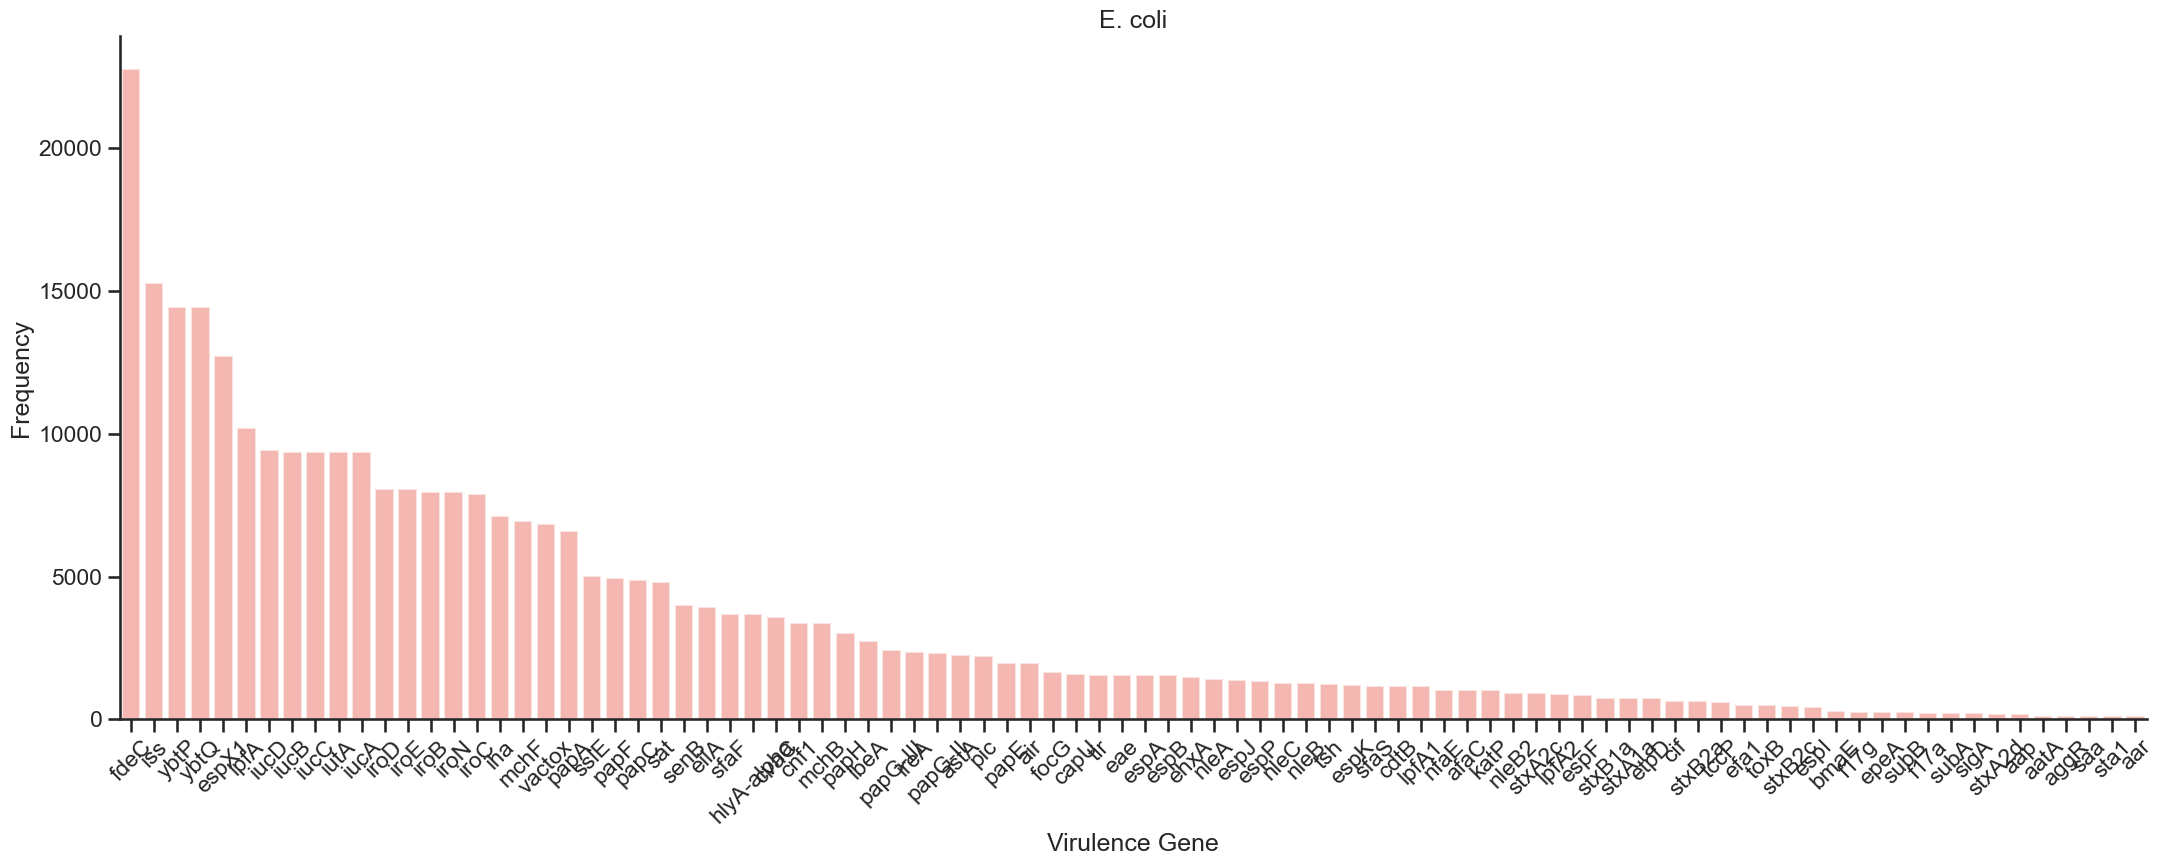

In [18]:
plot_virulence_genes_frequency(vscore)

In [19]:
def virulence_score(df, vf_list, dic_unmatched):
    # Merge category mapping
    vf_map = dict(zip(vf_list['gene'], vf_list['category']))
    vf_map.update(dic_unmatched)
    genes_present = set(df.columns)

    # Define key gene sets
    ybt_genes = {'ybtP', 'ybtQ'} & genes_present
    score_1_genes = {'afaC'} | {'astA', 
                                'aggR', "aggA", "aggR",
                                'aatA'} | ybt_genes

    eaec_cluster = {'aggR', 'aatA', 'aap', "aar", "aafA", "aafB", "aafC", "aafD",
                    'aggA', 'aggB', 'aggC', 'aggD', 'agg4A', 'agg4D', 'agg5A',
                    "aafA", "aafB", "aafC", "aafD"} & genes_present
    
    epec_cluster = {'eae', 'tir', 'bfpA'} & genes_present
    
    upec_cluster = {'papA', 'papC', 'papE', 'papF', 'papH', 'papG-I', 'papG-II', 
                    'papG-III', 'iroN', 'fimH', 'ireA', 'iha'} & genes_present
    
    toxins = {g for g, c in vf_map.items() if c == 'toxin'} & genes_present
    
    key_toxins = {'cnf1', 'espP', 'espF'} & genes_present
    
    aerobactins = {'iucA', 'iucB', 'iucC', 'iucD', 'iutA', 'iroD', 'iroE', 'iroN', 'iroC'} & genes_present
    
    invasion = {'ibeA'} & genes_present
    
    stx_genes = {g for g in genes_present if re.match(r'stx', g)}

    # Convert sets to lists for indexing
    def cols(s): return list(s & genes_present)

    # Masks
    df_sub = df.copy()
    df_sub['score'] = 0

    # Score 5
    df_sub.loc[
        (df[cols(aerobactins)].sum(axis=1) > 0) &
        (df[cols(ybt_genes)].sum(axis=1) > 0) &
        ((df[cols(key_toxins)].sum(axis=1) > 0) | (df[cols(stx_genes)].sum(axis=1) > 0)) &
        (df[cols(invasion)].sum(axis=1) > 0), 'score'
    ] = 5

    # Score 4
    mask_4 = (
        (df[cols(aerobactins)].sum(axis=1) > 0) &
        (df[cols(ybt_genes)].sum(axis=1) > 0) &
        ((df[cols(key_toxins)].sum(axis=1) > 0) | (df[cols(stx_genes)].sum(axis=1) > 0)) &
        (df_sub['score'] < 5)
    )
    df_sub.loc[mask_4, 'score'] = 4

    # Score 3
    mask_3 = (
        ((df[cols(key_toxins)].sum(axis=1) > 0) |
         (df[cols(eaec_cluster | epec_cluster)].sum(axis=1) >= 4)) &
        (df_sub['score'] < 4)
    )
    df_sub.loc[mask_3, 'score'] = 3

    # Score 2
    mask_2 = (
        ((df[cols(eaec_cluster)].sum(axis=1) >= 2) |
         (df[cols(epec_cluster)].sum(axis=1) >= 2) |
         (df[cols(upec_cluster)].sum(axis=1) >= 2)) &
        (df[cols(toxins)].sum(axis=1) == 0) &
        (df_sub['score'] < 3)
    )
    df_sub.loc[mask_2, 'score'] = 2

    # Score 1
    mask_1 = (
        (df[cols(score_1_genes)].sum(axis=1) > 0) &
        (df_sub['score'] == 0)
    )
    df_sub.loc[mask_1, 'score'] = 1

    return df_sub[['score']]

In [20]:
score = virulence_score(vscore, vir_categ, undefined_genes)

In [22]:
score.to_csv("../ecoli_virulence_score.tsv", sep="\t")

In [108]:
score_binary = score['score'].astype(pd.CategoricalDtype(categories=[0, 1, 2, 3, 4, 5]))
score_binary = pd.get_dummies(score_binary, prefix="score")
score_binary.index = score.index

In [113]:
def plot_virulencescore_frequency(df_binary):
    """
    Plots the frequency of virulence factor presence by category as a bar plot.

    Parameters:
    df_binary (pd.DataFrame): Binary VF DataFrame with 0s and 1s (Isolates x Categories).
    """
    ordered_cols = [f"score_{i}" for i in range(6) if f"score_{i}" in df_binary.columns]
    vir_frequencies = df_binary[ordered_cols].sum()

    if len(df_binary) <= 10:
        print(f"Not enough isolates to plot: {len(df_binary)} (≤10). Skipping plot.")
        return

    if (vir_frequencies < 10).all():
        print("No virulence scores with frequency ≥10. Skipping plot.")
        return

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(
        x=vir_frequencies.index,
        y=vir_frequencies.values,
        order=ordered_cols,
        color='xkcd:salmon',
        alpha=0.6,
        ax=ax
    )

    ax.set_xlabel("Virulence Score")
    ax.set_ylabel("Frequency")
    ax.set_title("E. coli")
    ax.set_facecolor("white")
    ax.tick_params(axis='x', rotation=45)

    sns.despine()
    plt.tight_layout()
    plt.savefig("../out/vir_score_ecoli.svg", format="svg", dpi=150)
    plt.savefig("../out/vir_score_ecoli.png", format="png", dpi=150)
    plt.show()

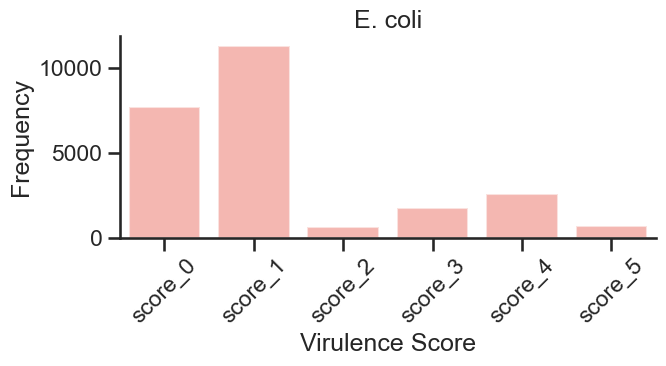

In [117]:
plot_virulencescore_frequency(score_binary)